# Sales Prediction using Python
**CodeAlpha Data Science Internship - Task 4**

Goal: predict sales from advertising spend (TV, Radio, Newspaper) and find which channel drives sales most.

Place `Advertising.csv` in the same folder as this notebook.

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
file = (glob.glob("*dvertising*.csv") + glob.glob("*ales*.csv") + glob.glob("**/*dvertising*.csv", recursive=True))[0]
df = pd.read_csv(file)
print("Loaded:", file)
df.head()

Loaded: Advertising.csv


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 1. Cleaning

In [2]:
df = df.drop(columns=[c for c in df.columns if "unnamed" in c.lower()])
print(df.shape)
df.info()
print("\nMissing values:\n", df.isnull().sum())
df = df.drop_duplicates().dropna().reset_index(drop=True)

target = [c for c in df.columns if c.lower() == "sales"][0]
features = [c for c in df.select_dtypes("number").columns if c != target]
print("Target:", target, "| Features:", features)
df.describe()

(200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Missing values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
Target: Sales | Features: ['TV', 'Radio', 'Newspaper']


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## 2. Exploratory analysis

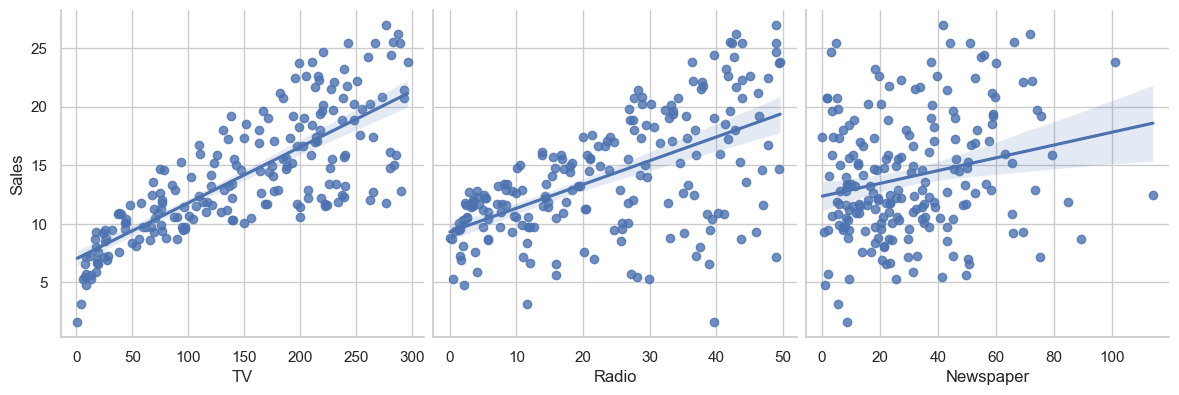

In [3]:
sns.pairplot(df, x_vars=features, y_vars=target, height=4, kind="reg")
plt.show()

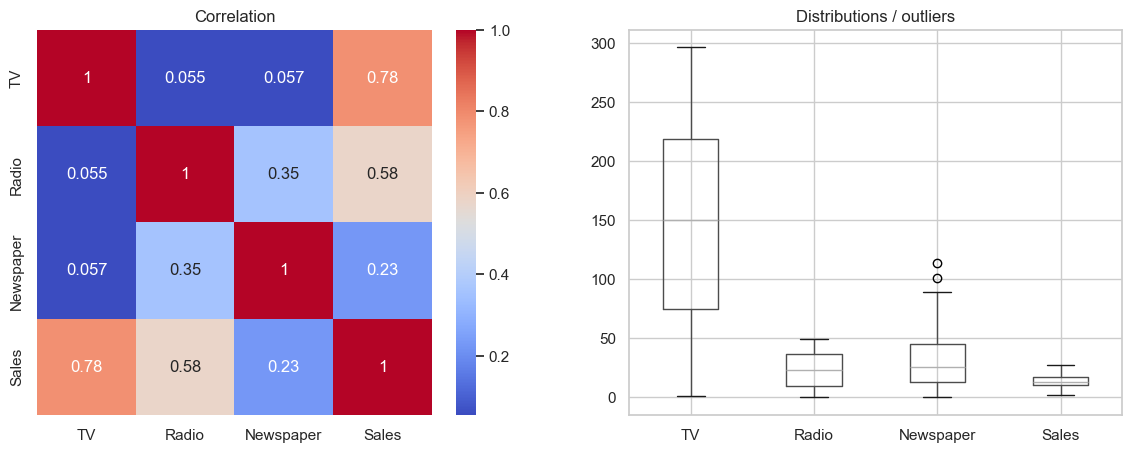

TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", ax=axes[0]).set_title("Correlation")
df[features + [target]].boxplot(ax=axes[1])
axes[1].set_title("Distributions / outliers")
plt.show()
print(df.corr(numeric_only=True)[target].drop(target).sort_values(ascending=False))

## 3. Train / test split

In [5]:
X, y = df[features], df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (160, 3) Test: (40, 3)


## 4. Compare models

In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}
rows = []
for name, m in models.items():
    cv = cross_val_score(m, X_train, y_train, cv=5, scoring="r2").mean()
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    rows.append([name, cv, r2_score(y_test, p), mean_absolute_error(y_test, p), np.sqrt(mean_squared_error(y_test, p))])
results = pd.DataFrame(rows, columns=["Model", "CV R2", "Test R2", "MAE", "RMSE"]).set_index("Model")
results.round(3)

,CV R2,Test R2,MAE,RMSE
Model,,,,
Linear Regression,0.859,0.899,1.461,1.782
Ridge,0.859,0.899,1.461,1.782
Random Forest,0.970,0.982,0.629,0.757
Gradient Boosting,0.970,0.983,0.619,0.730


## 5. Final model evaluation

Best model: Gradient Boosting
R2   : 0.9831
MAE  : 0.6187
RMSE : 0.7298


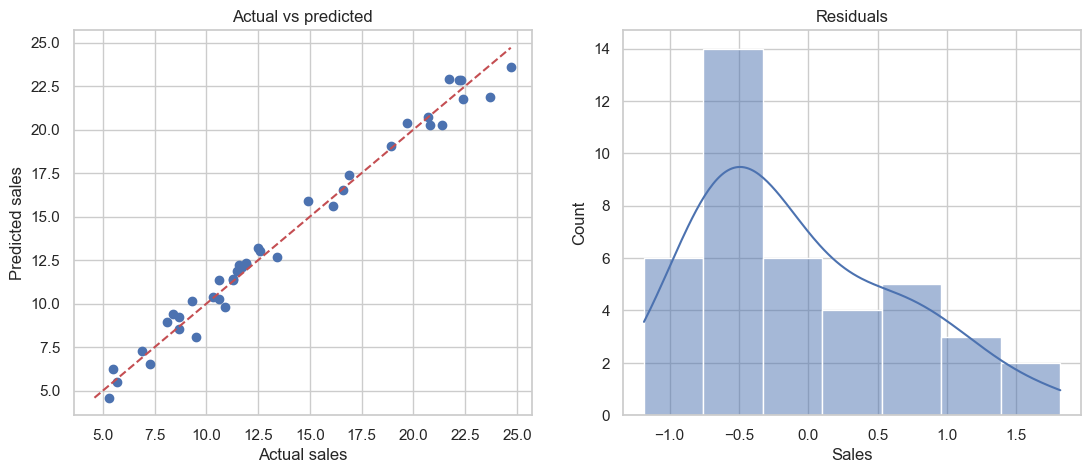

In [7]:
best_name = results["Test R2"].idxmax()
best = models[best_name]
pred = best.predict(X_test)
print("Best model:", best_name)
print(f"R2   : {r2_score(y_test, pred):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, pred)):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, pred)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[0].plot(lims, lims, "r--")
axes[0].set(xlabel="Actual sales", ylabel="Predicted sales", title="Actual vs predicted")
sns.histplot(y_test - pred, kde=True, ax=axes[1]).set_title("Residuals")
plt.show()

## 6. How does advertising impact sales?

Intercept: 2.939
Effect on sales of +1 unit of spend in each channel:
Newspaper   -0.0010
TV           0.0458
Radio        0.1885
dtype: float64


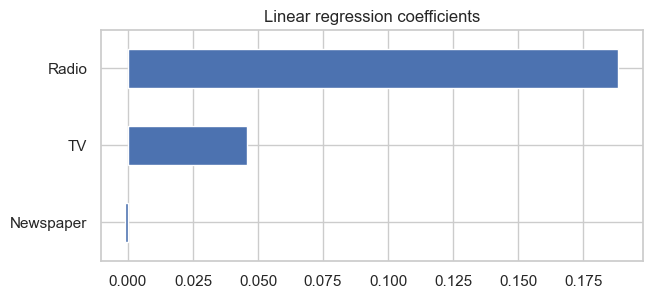

In [8]:
lr = LinearRegression().fit(X, y)
coef = pd.Series(lr.coef_, index=features).sort_values()
print(f"Intercept: {lr.intercept_:.3f}")
print("Effect on sales of +1 unit of spend in each channel:")
print(coef.round(4))
coef.plot(kind="barh", figsize=(7, 3), title="Linear regression coefficients")
plt.show()

In [9]:
# What-if simulation: increase one channel's budget by 10 units, keep the others at their average
base = X.mean().to_frame().T
base_pred = lr.predict(base)[0]
for f in features:
    scenario = base.copy()
    scenario[f] += 10
    print(f"+10 {f:10s} -> sales change: {lr.predict(scenario)[0] - base_pred:+.3f}")

+10 TV         -> sales change: +0.458
+10 Radio      -> sales change: +1.885
+10 Newspaper  -> sales change: -0.010


In [10]:
# Predict sales for a custom budget (edit the numbers)
budget = {f: float(X[f].median()) for f in features}
print("Budget used:", budget)
print("Predicted sales:", round(best.predict(pd.DataFrame([budget]))[0], 2))

Budget used: {'TV': 149.75, 'Radio': 22.9, 'Newspaper': 25.75}
Predicted sales: 14.61


## Business insights
1. **TV** advertising has the strongest relationship with sales, followed closely by **Radio**.
2. **Newspaper** spend has a weak or negligible effect once TV and Radio are accounted for - budget there is the first candidate to cut or reallocate.
3. A simple linear model already explains most of the variance in sales (R2 around 0.9), so the relationship is mostly linear.
4. **Recommendation:** shift budget towards TV and Radio, keep tracking returns per channel, and re-train the model as new campaign data arrives.